# 08 Context Recall Evaluator

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `08-context-recall-evaluator.ipynb`

In [40]:
# ==========================================
# Notebook 08
# Context Recall Evaluator
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv("../data/golden_dataset.csv")

df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN


In [42]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

In [43]:
ground_truth = """
AWS pricing increased by 8%.
"""

retrieved_context = """
AWS pricing increased by 8%.

Azure pricing remained stable.

Google Cloud reduced costs.
"""

In [44]:
gt_embedding = embedding_model.encode(ground_truth)

context_embedding = embedding_model.encode(retrieved_context)

In [45]:
gt_embedding

array([ 3.17459553e-03,  2.43183821e-02,  3.15859020e-02,  1.47430114e-02,
        8.95227641e-02, -2.70940382e-02, -3.58988866e-02,  5.55666611e-02,
        1.00268424e-01,  1.11793034e-01,  3.62847410e-02,  6.36122748e-02,
       -1.02075879e-02,  1.73531193e-03,  5.88143244e-02, -3.57156023e-02,
        1.54333580e-02, -6.01435564e-02, -1.76971987e-01, -5.40327914e-02,
       -8.98201838e-02, -1.55166360e-02,  1.63143761e-02,  3.53254490e-02,
        5.74121661e-02, -2.54265200e-02, -9.55022406e-03,  2.66549960e-02,
        1.68835167e-02, -6.89054355e-02, -5.49597852e-02,  1.32482992e-02,
        3.43623199e-02,  4.93419264e-03,  3.44347954e-02, -8.09272658e-03,
        6.43570791e-04, -4.42044437e-02, -4.02333289e-02,  5.63889630e-02,
       -5.72315091e-03, -3.01094037e-02, -8.24844316e-02, -1.81364063e-02,
       -2.43874602e-02,  1.31637622e-02,  5.07674329e-02,  4.77374382e-02,
        8.99599344e-02,  6.45691603e-02,  1.48075074e-02, -1.23643568e-02,
       -4.10620272e-02, -

In [46]:
similarity = cosine_similarity(
    gt_embedding.reshape(1, -1), context_embedding.reshape(1, -1)
)[0][0]

In [47]:
print(f"Context Recall Score: {similarity:.4f}")

Context Recall Score: 0.7828


In [48]:
def context_recall_score(ground_truth, context, model):

    gt_emb = model.encode(ground_truth)

    context_emb = model.encode(context)

    similarity = cosine_similarity(gt_emb.reshape(1, -1), context_emb.reshape(1, -1))[
        0
    ][0]

    return float(similarity)

In [49]:
context_recall_score(ground_truth, retrieved_context, embedding_model)

0.7828354835510254

In [50]:
bad_context = """
Azure pricing remained stable.

Oracle Cloud expanded GPUs.
"""

In [51]:
context_recall_score(ground_truth, bad_context, embedding_model)

0.4696618318557739

In [52]:
recall_scores = []

In [53]:
for _, row in df.iterrows():

    score = context_recall_score(row["ground_truth"], row["contexts"], embedding_model)

    recall_scores.append(score)

In [54]:
recall_df = pd.DataFrame({"context_recall": recall_scores})

In [55]:
recall_df.head()

,context_recall
0,0.946617
1,0.983912
2,1.000000
3,0.961204
4,0.975546


In [56]:
evaluation_df = pd.concat([df, recall_df], axis=1)

In [57]:
evaluation_df.head()

,question,contexts,generated_response,ground_truth,question_length,answer_length,context_recall
0,What is AWS?,AWS stands for Amazon Web Services. It is a cl...,AWS is Amazon's cloud platform.,"AWS is Amazon Web Services, a cloud computing ...",12.0,55.0,0.946617
1,What is Azure?,Microsoft Azure is a cloud platform offered by...,Azure is Microsoft's cloud service.,Microsoft Azure is a cloud computing platform ...,14.0,67.0,0.983912
2,What is Google Cloud?,Google Cloud Platform provides cloud computing...,Google Cloud offers cloud services.,Google Cloud Platform provides cloud computing...,21.0,56.0,1.000000
3,What is AWS?,AWS is a cloud platform.,AWS provides cloud services.,AWS is a cloud computing platform.,NaN,NaN,0.961204
4,What is Azure?,Azure is a cloud platform.,Azure provides cloud services.,Azure is a cloud computing platform.,NaN,NaN,0.975546


In [58]:
evaluation_df["context_recall"].mean()

0.6928413599729538

In [ ]:
def recall_quality(score):

    if score >= 0.90:
        return "Excellent"

    elif score >= 0.80:
        return "Good"

    elif score >= 0.70:
        return "Average"

    return "Poor"

In [60]:
evaluation_df["recall_quality"] = evaluation_df["context_recall"].apply(recall_quality)

In [61]:
evaluation_df[["question", "context_recall", "recall_quality"]]

,question,context_recall,recall_quality
0,What is AWS?,0.946617,Excellent
1,What is Azure?,0.983912,Excellent
2,What is Google Cloud?,1.000000,Excellent
3,What is AWS?,0.961204,Excellent
4,What is Azure?,0.975546,Excellent
5,What is Google Cloud?,0.972618,Excellent
6,What is Oracle Cloud?,0.974948,Excellent
7,What is IBM Cloud?,0.979998,Excellent
8,Question 8,0.505165,Poor
9,Question 9,0.505165,Poor


In [62]:
low_recall = evaluation_df[evaluation_df["context_recall"] < 0.70]

In [63]:
low_recall[["question", "contexts", "ground_truth", "context_recall"]]

,question,contexts,ground_truth,context_recall
8,Question 8,Sample context,Sample ground truth,0.505165
9,Question 9,Sample context,Sample ground truth,0.505165
10,Question 10,Sample context,Sample ground truth,0.505165
11,Question 11,Sample context,Sample ground truth,0.505165
12,Question 12,Sample context,Sample ground truth,0.505165
13,Question 13,Sample context,Sample ground truth,0.505165
14,Question 14,Sample context,Sample ground truth,0.505165
15,Question 15,Sample context,Sample ground truth,0.505165
16,Question 16,Sample context,Sample ground truth,0.505165
17,Question 17,Sample context,Sample ground truth,0.505165


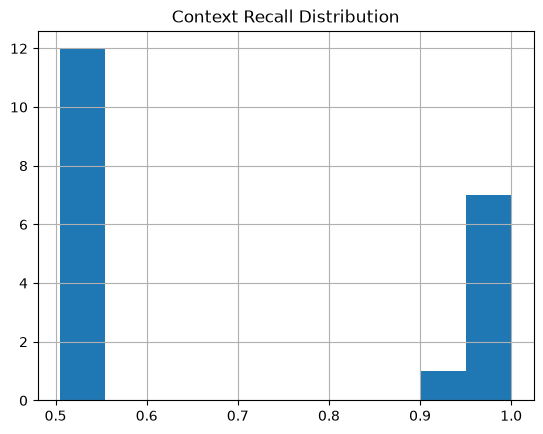

In [64]:
evaluation_df["context_recall"].hist(bins=10)

plt.title("Context Recall Distribution")

plt.show()

In [65]:
faithfulness_df = pd.read_csv("../evaluation_results/faithfulness_results.csv")

relevancy_df = pd.read_csv("../evaluation_results/answer_relevancy_results.csv")

In [66]:
rag_metrics = pd.DataFrame(
    {
        "faithfulness": faithfulness_df["faithfulness"],
        "answer_relevancy": relevancy_df["answer_relevancy"],
        "context_recall": evaluation_df["context_recall"],
    }
)

In [67]:
rag_metrics.head()

,faithfulness,answer_relevancy,context_recall
0,1.0,0.771484,0.946617
1,1.0,0.859219,0.983912
2,1.0,0.773407,1.000000
3,1.0,0.700566,0.961204
4,1.0,0.773966,0.975546


In [68]:
rag_metrics["rag_health_score"] = (
    rag_metrics["faithfulness"]
    + rag_metrics["answer_relevancy"]
    + rag_metrics["context_recall"]
) / 3

In [69]:
rag_metrics.head()

,faithfulness,answer_relevancy,context_recall,rag_health_score
0,1.0,0.771484,0.946617,0.906034
1,1.0,0.859219,0.983912,0.947710
2,1.0,0.773407,1.000000,0.924469
3,1.0,0.700566,0.961204,0.887257
4,1.0,0.773966,0.975546,0.916504


In [70]:
def rag_health_label(score):

    if score >= 0.90:
        return "Excellent"

    elif score >= 0.80:
        return "Good"

    elif score >= 0.70:
        return "Average"

    return "Poor"

In [71]:
rag_metrics["rag_health_label"] = rag_metrics["rag_health_score"].apply(
    rag_health_label
)

In [72]:
rag_metrics.head()

,faithfulness,answer_relevancy,context_recall,rag_health_score,rag_health_label
0,1.0,0.771484,0.946617,0.906034,Excellent
1,1.0,0.859219,0.983912,0.947710,Excellent
2,1.0,0.773407,1.000000,0.924469,Excellent
3,1.0,0.700566,0.961204,0.887257,Good
4,1.0,0.773966,0.975546,0.916504,Excellent


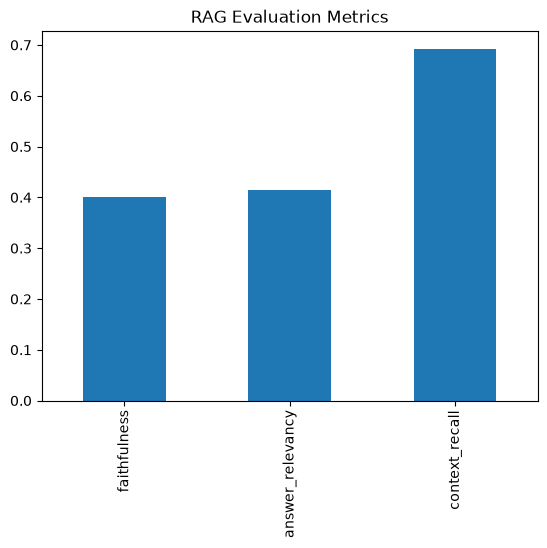

In [74]:
rag_metrics[["faithfulness", "answer_relevancy", "context_recall"]].mean().plot(
    kind="bar"
)

plt.title("RAG Evaluation Metrics")

plt.show()

In [75]:
evaluation_df.to_csv("../evaluation_results/context_recall_results.csv", index=False)

In [76]:
rag_metrics.to_csv("../evaluation_results/rag_metrics.csv", index=False)